# Programming Assignment 1

Segmentação de instâncias com as arquiteturas da aula

Equipe: Jaime Willian Carneiro da Silva & Luiz Eduardo Bravin

In [1]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, random_split, Dataset
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
from sklearn.cluster import DBSCAN
import torch.nn.functional as F

## Datasets 

Escolheremos a opção A - DSB2018 / BBBC038v1

Download:  https://bbbc.broadinstitute.org/BBBC038

In [2]:
def generate_image(img_size: int, seed: int = None):
    image = np.zeros((img_size, img_size, 3), dtype= np.uint8)
    rng = np.random.default_rng(seed=seed)
    num_ellipses = int(rng.integers(5, 21))
    instance_masks = np.zeros((num_ellipses, img_size, img_size), dtype= np.uint8)
    
    for idx in range(num_ellipses):
        center = tuple(rng.integers(0, img_size + 1, size=2).tolist())
        axes = tuple(rng.integers(5, 41, size=2).tolist())
        angle = int(rng.integers(0, 101))
        color = tuple(rng.integers(50, 256, size=3).tolist())
    
        cv.ellipse(image, center, axes, angle, 0, 360, color, -1)
        cv.ellipse(instance_masks[idx], center, axes, angle, 0, 360, 1, -1)
        
    contrast = rng.random() + 0.5
    noise = rng.integers(-20, 20, size=(img_size, img_size, 3))
    image = (image * contrast) + noise
    image = np.clip(image, 0 , 255 ).astype(np.uint8)

    return image, instance_masks


def to_tensors(image: np.ndarray, instance_masks: np.ndarray):
    image_tensor = torch.from_numpy(image.transpose((2, 0, 1))).float() / 255.0

    binary_mask = (instance_masks.sum(axis=0) > 0).astype(np.float32)
    binary_mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0)

    instance_gt = np.zeros(instance_masks.shape[1:], dtype=np.int32)
    for i, mask in enumerate(instance_masks):
        instance_gt[mask > 0] = i + 1
        
    return image_tensor, binary_mask_tensor, instance_gt


In [3]:
class SyntheticEllipseDataset(Dataset):
    def __init__(self, num_samples: int, img_size: int = 128, seed: int = None) -> None:
        super().__init__()
        self.num_samples = num_samples
        self.img_size = img_size
        self.seed = seed

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        seed = None if self.seed is None else self.seed + idx
        image, instance_masks = generate_image(self.img_size, seed=seed)            
        return to_tensors(image, instance_masks)


class DSB2018Dataset(Dataset):
    def __init__(self, root_dir: str, img_size: int = 128, sample_ids: list = None):
        super().__init__()
        self.root_dir = Path(root_dir)
        self.img_size = img_size
        self.sample_ids = sample_ids or sorted(
            p.name for p in self.root_dir.iterdir() if p.is_dir()
        )

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_dir = self.root_dir / self.sample_ids[idx]

        image_path = next((sample_dir / "images").glob("*.png"))
        image = cv.imread(str(image_path), cv.IMREAD_COLOR)
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        image = cv.resize(image, (self.img_size, self.img_size), interpolation=cv.INTER_LINEAR)

        mask_paths = sorted((sample_dir / "masks").glob("*.png"))
        instance_masks = np.zeros((len(mask_paths), self.img_size, self.img_size), dtype=np.uint8)
        for i, mask_path in enumerate(mask_paths):
            mask = cv.imread(str(mask_path), cv.IMREAD_GRAYSCALE)
            mask = cv.resize(mask, (self.img_size, self.img_size), interpolation=cv.INTER_NEAREST)
            instance_masks[i] = (mask > 127).astype(np.uint8)

        return to_tensors(image, instance_masks)



In [4]:
def build_dataset(dataset_type: str, **kwargs):
    if dataset_type == "synthetic":
        return SyntheticEllipseDataset(**kwargs)
    elif dataset_type == "real":
        return DSB2018Dataset(**kwargs)

## Modelo

In [5]:
class UNetBinary(nn.Module):
    def __init__(self) :
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        # ENCODER
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu) # 64x64
        self.pool = resnet.maxpool # 32x32
        self.enc2 = resnet.layer1  # 32x32, 64 canais
        self.enc3 = resnet.layer2  # 16x16, 128 canais
        self.enc4 = resnet.layer3  # 8x8, 256 canais

        # DECODER
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, 1, kernel_size=1) # 1 canal de saída (máscara binária)
        
    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)

        d3 = self.dec3(torch.cat([self.up3(x4), x3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), x2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), x1], dim=1))

        return self.final_conv(self.up0(d1))


class UNetDDimensional(nn.Module):
    def __init__(self, D=1) :
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        # ENCODER
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu) # 64x64
        self.pool = resnet.maxpool # 32x32
        self.enc2 = resnet.layer1  # 32x32, 64 canais
        self.enc3 = resnet.layer2  # 16x16, 128 canais
        self.enc4 = resnet.layer3  # 8x8, 256 canais

        # DECODER
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.semantic_head = nn.Conv2d(32, 1, kernel_size=1) 
        self.embed_head = nn.Conv2d(32, D, 1) # D canais de saída

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)

        d3 = self.dec3(torch.cat([self.up3(x4), x3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), x2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), x1], dim=1))
        d0 = self.up0(d1)
        
        return self.semantic_head(d0),  self.embed_head(d0) 


def discrimative_loss(prediction, instance, delta_d=1.5):
    batch_size = prediction.size(0)
    total_loss = prediction.sum() * 0.0 
    
    for b in range(batch_size):
        pred_b = prediction[b] # [C, H, W]
        inst_b = instance[b]   # [H, W]
        objects_ids = torch.unique(inst_b)[1:] 
        var_loss = 0.0
        dist_loss = 0.0
        reg_loss = 0.0
        centroids = []

        for obj_id in objects_ids:
            mask = (inst_b == obj_id)
            pixels = pred_b[:, mask] 
            
            avg = torch.mean(pixels, dim=1)
            var = torch.mean(torch.norm(pixels - avg.unsqueeze(1), dim=0))
            var_loss += var
            reg_loss += torch.norm(avg)
            centroids.append(avg)
            
        num_centroids = len(centroids)
        if num_centroids == 0: 
            continue
            
        if num_centroids > 1:
            centroids_tensor = torch.stack(centroids) 
            dists = torch.cdist(centroids_tensor, centroids_tensor, p=2.0)
            triu_idx = torch.triu_indices(num_centroids, num_centroids, offset=1)
            pairwise_dists = dists[triu_idx[0], triu_idx[1]]
            dist_loss = torch.clamp(delta_d - pairwise_dists, min=0).sum()
        loss_emb = (reg_loss + dist_loss + var_loss) / num_centroids
        total_loss += loss_emb
        
    return total_loss / batch_size

def train_model(model, dataloader, device, part: int, lr: float = 1e-3, num_epochs: int = 5):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    num_batchs = len(dataloader)

    for epoch in range(num_epochs):
        model.train()
        accumulated_loss = 0.0
        total_intersection = 0.0
        total_union = 0.0
        
        for images, masks, instance_gt in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            if part == 1:
                optimizer.zero_grad()
                prediction_bin = model(images)
                loss = criterion(prediction_bin, masks)
            elif part == 2:
                instance_gt = instance_gt.to(device)
                optimizer.zero_grad()
                prediction_bin, prediction_emb = model(images)
                loss_bin = criterion(prediction_bin, masks)
                loss_emb = discrimative_loss(prediction_emb, instance_gt)
                loss = loss_bin + loss_emb
            loss.backward()
            optimizer.step()

            binary_prediction = (torch.sigmoid(prediction_bin) > 0.5).float()
            intersection = (binary_prediction * masks).sum()
            union = binary_prediction.sum() + masks.sum() - intersection
            
            accumulated_loss += loss.item()
            total_intersection += intersection.item()
            total_union += union.item()
            
        epoch_iou = total_intersection / (total_union + 1e-6)
        epoch_dice = (2.0 * total_intersection) / (total_union + total_intersection + 1e-6)
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {accumulated_loss/num_batchs:.4f} | IoU: {epoch_iou:.4f} | Dice: {epoch_dice:.4f}")

## Métricas

A regra de matching utilizada foi a guloso por IoU.

In [6]:
def calculate_instance_metrics(true_instances, pred_instances):
    true_ids = np.unique(true_instances)[1:] # Remove the background label (0)
    pred_ids = np.unique(pred_instances)[1:] # Remove the background label (0)

    # Absolute count error
    num_true_objects = len(true_ids)
    num_pred_objects = len(pred_ids)
    count_error = abs(num_pred_objects - num_true_objects)

    # Extreme cases: no objects in either true or predicted masks
    if num_true_objects == 0 and num_pred_objects == 0:
        return 1.0, count_error, num_true_objects
    if num_true_objects == 0 or num_pred_objects == 0:
        return 0.0, count_error, num_true_objects

    # IoU Matrix Calculation
    iou_matrix = np.zeros((num_true_objects, num_pred_objects))
    for i, t_id in enumerate(true_ids):
        t_mask = (true_instances == t_id)
        for j, p_id in enumerate(pred_ids):
            p_mask = (pred_instances == p_id)
            intersection = np.logical_and(t_mask, p_mask).sum()
            if intersection > 0:
                union = np.logical_or(t_mask, p_mask).sum()
                iou_matrix[i, j] = intersection / union
    sorted_indices = np.argsort( iou_matrix.flatten())[::-1]
    shape = iou_matrix.shape

    #  Calculate Average Precision 
    aps = []
    for t in np.arange(0.5, 1.0, 0.05):
        tp = 0
        matched_true = set()
        matched_pred = set()
        for idx in sorted_indices:
            t_idx, p_idx = np.unravel_index(idx, shape)
            iou = iou_matrix[t_idx, p_idx]
            if iou < t:
                break
            if t_idx not in matched_true and p_idx not in matched_pred:
                tp += 1 # só os diferentes
                matched_true.add(t_idx)
                matched_pred.add(p_idx)
                
        fp = num_pred_objects - tp
        fn = num_true_objects - tp
        ap = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        aps.append(ap)
        
    mAP = np.mean(aps)
    
    return mAP, count_error, num_true_objects


def embeddings_to_instances(pred_bin, pred_emb, eps =0.5, min_samples = 10):
    mask = (torch.sigmoid(pred_bin[0])>0.5).cpu().numpy()
    pred_instances = np.zeros(mask.shape, dtype=np.int32)
    if not mask.any():
        return pred_instances

    emb_foreground = (pred_emb[:, mask].T).cpu().numpy()
    
    model = DBSCAN(eps= eps, min_samples= min_samples)
    labels = model.fit_predict(emb_foreground) + 1
    pred_instances[mask]= labels

    return pred_instances

def evaluate(model, dataloader, device, part: int):
    model.eval()
    all_mAPs = []
    all_count_errors = []
    all_densities = []

    for images, _, real_instances in dataloader:
        with torch.no_grad():
            if part == 1:
                binary_preds = (torch.sigmoid(model(images.to(device))) > 0.5).float().cpu().numpy()
            elif part == 2:
                binary_preds, embed_preds = model(images.to(device)) 
        real_instances = real_instances.numpy()

        for i in range(images.size(0)):
            if part == 1:
                pred_instances = np.squeeze(binary_preds[i, 0])
                pred_instances = cv.connectedComponents(pred_instances.astype(np.uint8))[1]
                mAP, count_error, density = calculate_instance_metrics(
                    real_instances[i],
                    pred_instances
                )
            elif part == 2:
                pred_instances = embeddings_to_instances(binary_preds[i], embed_preds[i])
                mAP, count_error, density = calculate_instance_metrics(
                    real_instances[i],
                    pred_instances
                )
            all_mAPs.append(mAP)
            all_count_errors.append(count_error)
            all_densities.append(density)
            
    return all_mAPs, all_count_errors, all_densities


def plot_metrics(all_mAPs, all_count_errors, all_densities):
    """Imprime as médias globais e plota os gráficos de falha baseados na densidade."""
    print(f"Média global mAP: {np.mean(all_mAPs):.4f}")
    print(f"Média global Erro Absoluto de Contagem: {np.mean(all_count_errors):.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(10, 6))

    color = 'tab:blue'
    ax[0].set_xlabel('Densidade de Objetos (Qtd. de Instâncias Reais)')
    ax[0].set_ylabel('mAP (Threshold 0.5 a 0.95)', color=color)
    ax[0].scatter(all_densities, all_mAPs, color=color, alpha=0.6, label='mAP')
    ax[0].tick_params(axis='y', labelcolor=color)
    ax[0].spines['right'].set_visible(False)
    ax[0].spines['top'].set_visible(False)
    ax[0].set_title("Quantificação de Falhas: Desempenho vs. Densidade", fontsize = 10, fontweight='bold')

    color = 'tab:red'
    ax[1].set_ylabel('Erro Absoluto de Contagem', color=color)
    ax[1].scatter(all_densities, all_count_errors, color=color, alpha=0.6, label='Erro de Contagem')
    ax[1].set_xlabel('Densidade de Objetos (Qtd. de Instâncias Reais)')
    ax[1].tick_params(axis='y', labelcolor=color)
    ax[1].spines['right'].set_visible(False)
    ax[1].spines['top'].set_visible(False)
    ax[1].set_title("Quantificação de Falhas: Desempenho vs. Densidade", fontsize = 10,  fontweight='bold')
    plt.grid(False)
    fig.tight_layout()
    plt.show()

Parte 0 - Teste Unitário

In [7]:
# Created the synthetic images 
synthetic_train = build_dataset("synthetic", num_samples=536, img_size=128)
synthetic_val = build_dataset("synthetic", num_samples=134, img_size=128)
synthetic_test = build_dataset("synthetic", num_samples=65, img_size=128)
print(f"Synthetic Train: {len(synthetic_train)}, Synthetic Val: {len(synthetic_val)}, Synthetic Test: {len(synthetic_test)}")

# Create data loaders
synthetic_train_loader = DataLoader(synthetic_train, batch_size=8, shuffle=True)
synthetic_val_loader = DataLoader(synthetic_val, batch_size=8, shuffle=False)
synthetic_test_loader = DataLoader(synthetic_test, batch_size=8, shuffle=False)

# Train and evaluate the model
synthetic_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
start = time.time()
train_model(synthetic_model, synthetic_train_loader, device, 1, num_epochs=5)
print(f"Training time: {(time.time() - start) / 60:.2f} minutes")


Synthetic Train: 536, Synthetic Val: 134, Synthetic Test: 65


KeyboardInterrupt: 

Média global mAP: 0.0959
Média global Erro Absoluto de Contagem: 9.5896


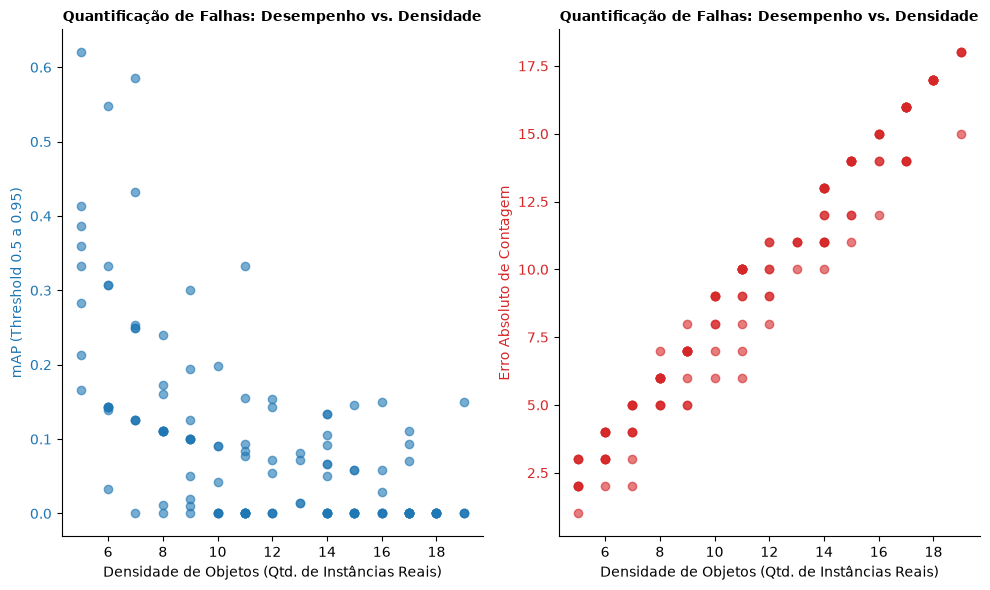

In [ ]:
plot_metrics(*evaluate(synthetic_model, synthetic_val_loader, device, part =1))


Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

Parte 1

In [8]:
# Extracted and formatted the images 
real_train_val = build_dataset("real", root_dir="./data/stage1_train", img_size=128)
real_train, real_val = random_split(real_train_val, [int(0.8 * len(real_train_val)), int(0.2 * len(real_train_val))])
real_test = build_dataset("real", root_dir="./data/stage1_test", img_size=128)
print(f"Real Train: {len(real_train)}, Real Val: {len(real_val)}, Real Test: {len(real_test)}")

# Create data loaders
real_train_loader = DataLoader(real_train, batch_size=8, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=8, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=8, shuffle=False)

# Train and evaluate the model
real_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_model(real_model, real_train_loader, device, part=1, num_epochs=10)


Real Train: 536, Real Val: 134, Real Test: 65
Epoch 1/10 | Loss: 0.2841 | IoU: 0.0017 | Dice: 0.0035
Epoch 2/10 | Loss: 0.1731 | IoU: 0.4288 | Dice: 0.6002
Epoch 3/10 | Loss: 0.1571 | IoU: 0.6457 | Dice: 0.7847
Epoch 4/10 | Loss: 0.1338 | IoU: 0.7067 | Dice: 0.8281
Epoch 5/10 | Loss: 0.1008 | IoU: 0.7441 | Dice: 0.8533
Epoch 6/10 | Loss: 0.1024 | IoU: 0.7414 | Dice: 0.8515
Epoch 7/10 | Loss: 0.0959 | IoU: 0.7581 | Dice: 0.8624
Epoch 8/10 | Loss: 0.0871 | IoU: 0.7723 | Dice: 0.8715
Epoch 9/10 | Loss: 0.0947 | IoU: 0.7581 | Dice: 0.8624
Epoch 10/10 | Loss: 0.0831 | IoU: 0.7824 | Dice: 0.8779


Média global mAP: 0.3796
Média global Erro Absoluto de Contagem: 17.9478


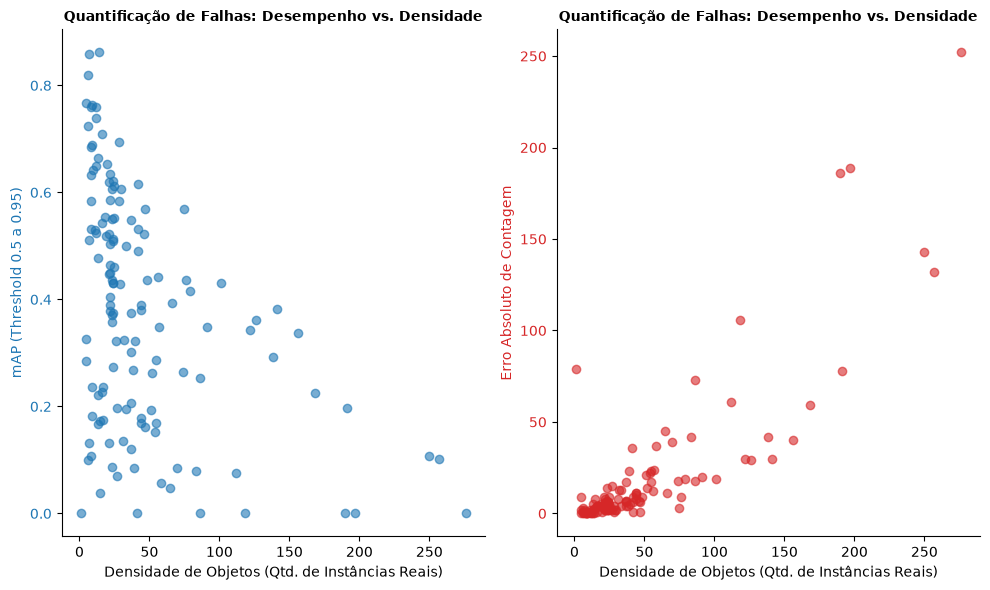

In [9]:
plot_metrics(*evaluate(real_model, real_val_loader, device, part=1))

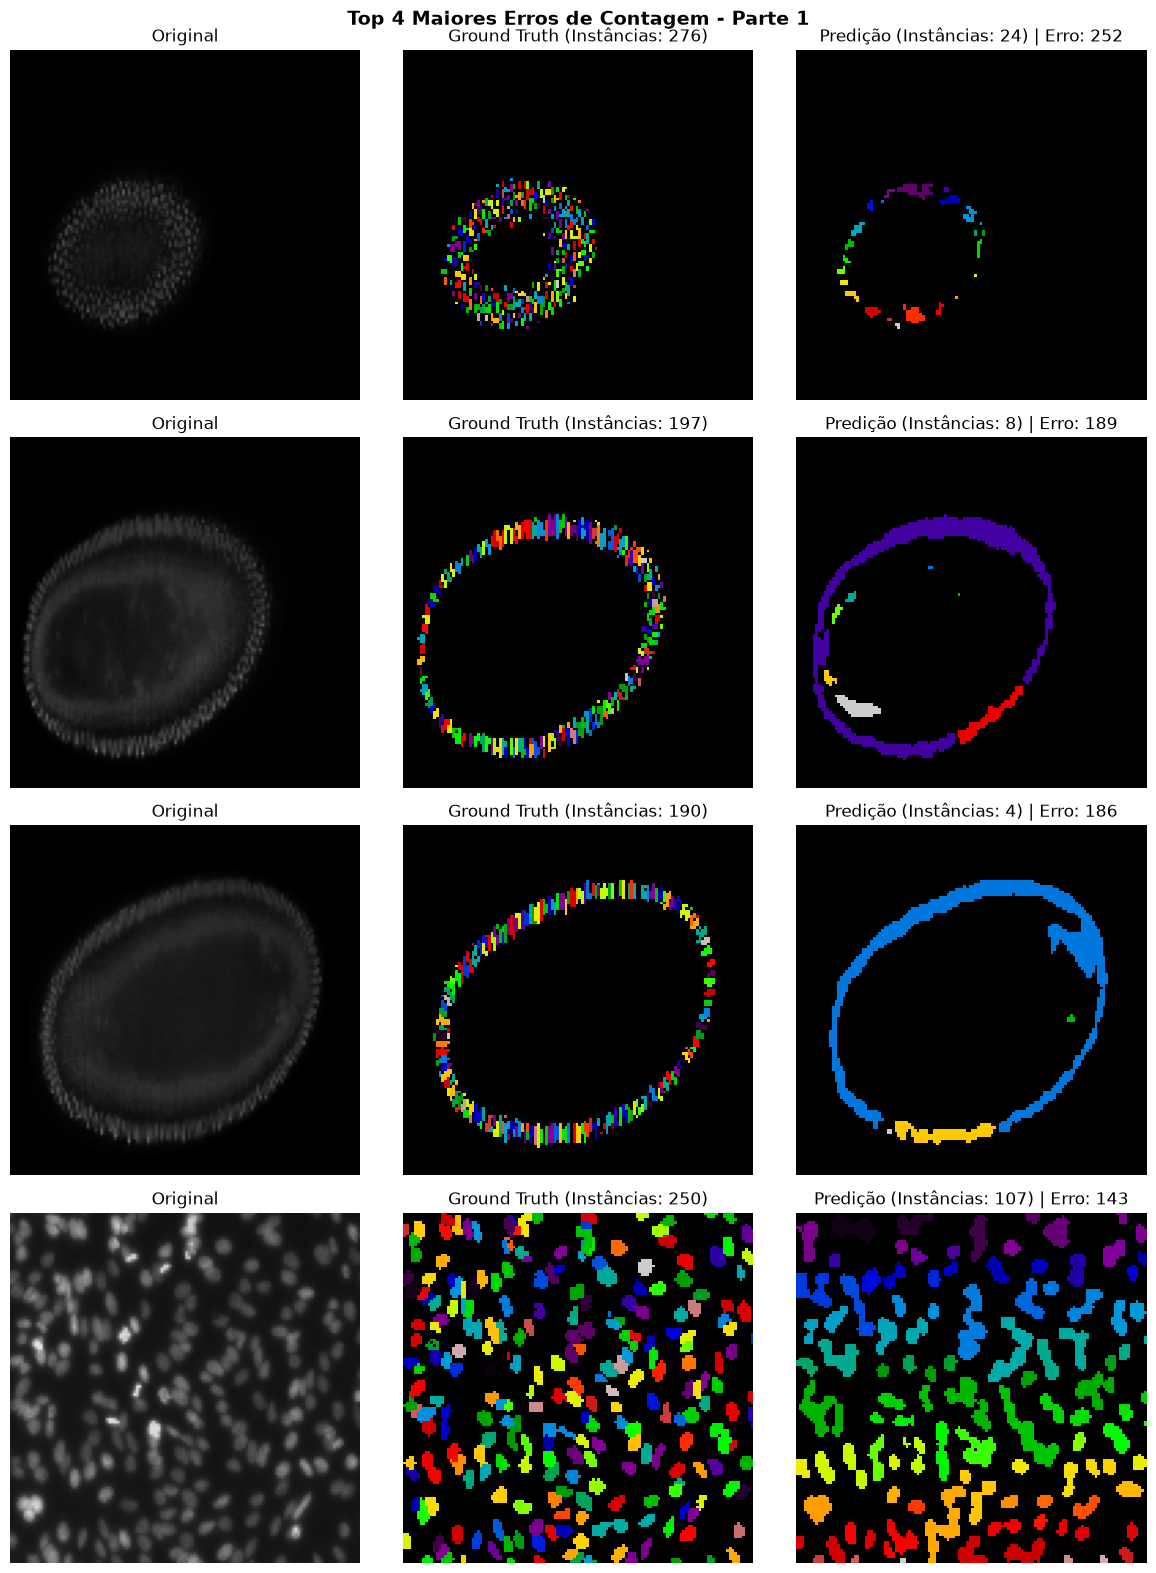

In [10]:
def evaluate_and_get_top_errors(model, dataloader, device, part: int, top_k: int = 4):
    model.eval()
    all_mAPs = []
    all_count_errors = []
    all_densities = []
    
    # Lista para rastrear os piores resultados: (count_error, image, real_mask, pred_mask)
    error_records = []

    for images, _, real_instances in dataloader:
        with torch.no_grad():
            if part == 1:
                binary_preds = (torch.sigmoid(model(images.to(device))) > 0.5).float().cpu().numpy()
            elif part == 2:
                binary_preds, embed_preds = model(images.to(device)) 
                
        real_instances_np = real_instances.numpy()

        for i in range(images.size(0)):
            if part == 1:
                pred_instances = np.squeeze(binary_preds[i, 0])
                pred_instances = cv.connectedComponents(pred_instances.astype(np.uint8))[1]
            elif part == 2:
                pred_instances = embeddings_to_instances(binary_preds[i], embed_preds[i])
                
            mAP, count_error, density = calculate_instance_metrics(
                real_instances_np[i],
                pred_instances
            )
            
            all_mAPs.append(mAP)
            all_count_errors.append(count_error)
            all_densities.append(density)
            
            # Transpor imagem (C, H, W) para (H, W, C) para o matplotlib
            img_plot = images[i].cpu().numpy().transpose(1, 2, 0)
            error_records.append((count_error, img_plot, real_instances_np[i], pred_instances))
            
    # Ordenar pelos maiores erros de contagem (decrescente) e pegar os top_k
    error_records.sort(key=lambda x: x[0], reverse=True)
    top_errors = error_records[:top_k]
            
    return all_mAPs, all_count_errors, all_densities, top_errors

def plot_top_errors(top_errors, part: int):
    """Renderiza uma matriz comparativa dos piores resultados."""
    fig, axes = plt.subplots(len(top_errors), 3, figsize=(12, 4 * len(top_errors)))
    fig.suptitle(f"Top {len(top_errors)} Maiores Erros de Contagem - Parte {part}", fontsize=14, fontweight='bold')

    for idx, (err, img, gt, pred) in enumerate(top_errors):
        # Imagem Original
        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title("Original")
        axes[idx, 0].axis('off')

        # Ground Truth
        # nipy_spectral ajuda a diferenciar instâncias distintas
        axes[idx, 1].imshow(gt, cmap='nipy_spectral', interpolation='nearest')
        axes[idx, 1].set_title(f"Ground Truth (Instâncias: {len(np.unique(gt))-1})")
        axes[idx, 1].axis('off')

        # Predição
        axes[idx, 2].imshow(pred, cmap='nipy_spectral', interpolation='nearest')
        axes[idx, 2].set_title(f"Predição (Instâncias: {len(np.unique(pred))-1}) | Erro: {err}")
        axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.show()


# Avaliação e plotagem da Parte 1
mAPs_1, errs_1, dens_1, top_errors_p1 = evaluate_and_get_top_errors(real_model, real_val_loader, device, part=1, top_k=4)
plot_top_errors(top_errors_p1, part=1)

# Avaliação e plotagem da Parte 2 (Certifique-se de usar o modelo treinado da Trilha B)
# mAPs_2, errs_2, dens_2, top_errors_p2 = evaluate_and_get_top_errors(real_model, real_val_loader, device, part=2, top_k=4)
# plot_top_errors(top_errors_p2, part=2)

Parte 2 - Trilha B

In [11]:
# Extracted and formatted the images 
real_train_val = build_dataset("real", root_dir="./data/stage1_train", img_size=128)
real_train, real_val = random_split(real_train_val, [int(0.8 * len(real_train_val)), int(0.2 * len(real_train_val))])
real_test = build_dataset("real", root_dir="./data/stage1_test", img_size=128)
print(f"Real Train: {len(real_train)}, Real Val: {len(real_val)}, Real Test: {len(real_test)}")

# Create data loaders
real_train_loader = DataLoader(real_train, batch_size=8, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=8, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=8, shuffle=False)

# Train and evaluate the model
real_model = UNetDDimensional(D=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_model(real_model, real_train_loader, device, part=2, num_epochs=10)


Real Train: 536, Real Val: 134, Real Test: 65
Epoch 1/10 | Loss: 10.5386 | IoU: 0.0352 | Dice: 0.0681
Epoch 2/10 | Loss: 4.7741 | IoU: 0.0000 | Dice: 0.0001
Epoch 3/10 | Loss: 4.4377 | IoU: 0.0000 | Dice: 0.0000
Epoch 4/10 | Loss: 4.1740 | IoU: 0.0006 | Dice: 0.0013
Epoch 5/10 | Loss: 4.0431 | IoU: 0.0443 | Dice: 0.0848
Epoch 6/10 | Loss: 3.9051 | IoU: 0.2563 | Dice: 0.4080
Epoch 7/10 | Loss: 3.7840 | IoU: 0.5263 | Dice: 0.6897
Epoch 8/10 | Loss: 3.7020 | IoU: 0.6034 | Dice: 0.7526
Epoch 9/10 | Loss: 3.6648 | IoU: 0.6429 | Dice: 0.7826
Epoch 10/10 | Loss: 3.6023 | IoU: 0.6604 | Dice: 0.7955


Média global mAP: 0.1340
Média global Erro Absoluto de Contagem: 29.5448


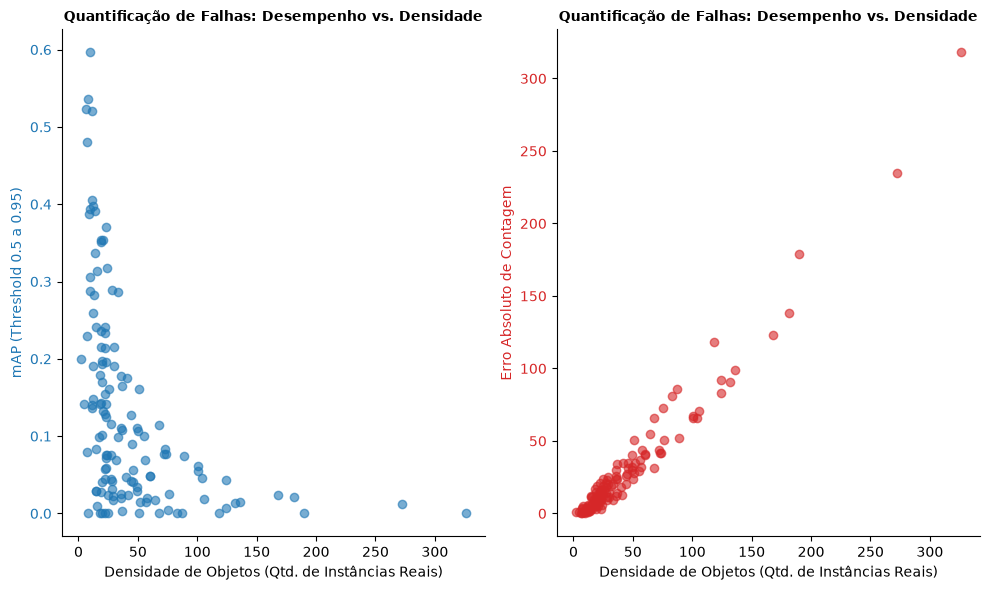

In [13]:
plot_metrics(*evaluate(real_model, real_val_loader, device, part =2))

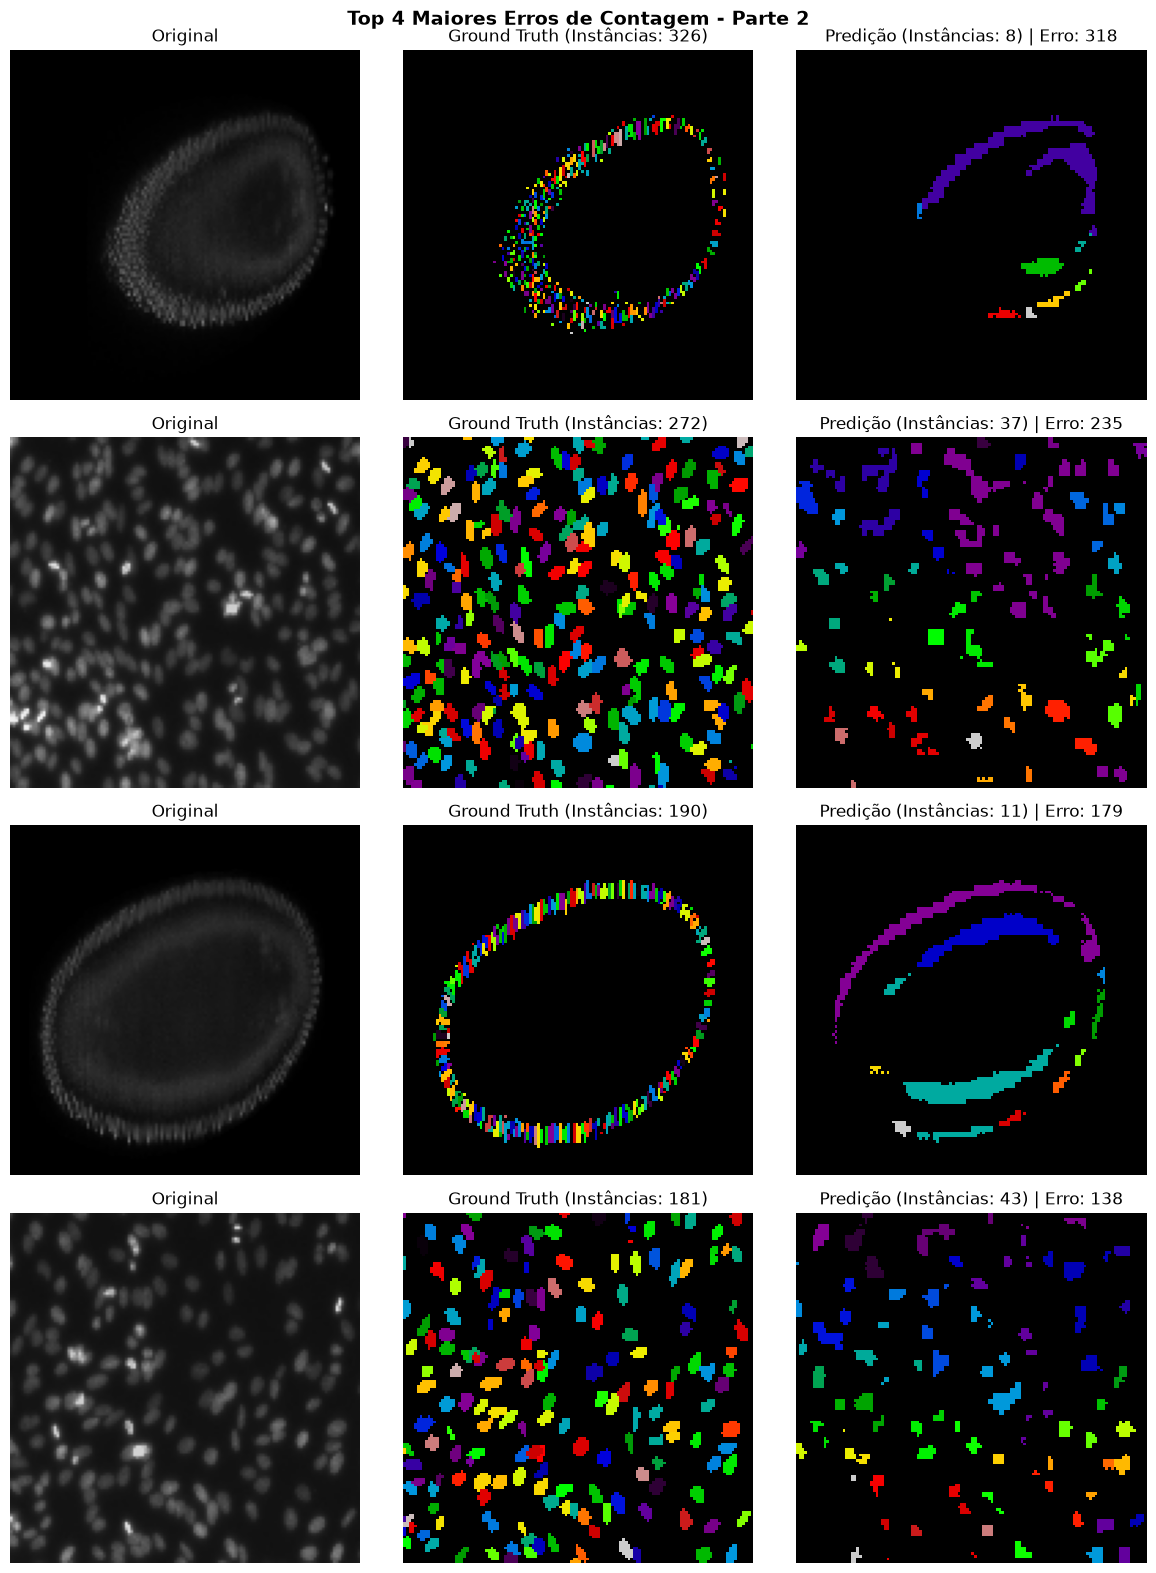

In [12]:
mAPs_2, errs_2, dens_2, top_errors_p2 = evaluate_and_get_top_errors(real_model, real_val_loader, device, part=2, top_k=4)
plot_top_errors(top_errors_p2, part=2)

## Part 3

Eixos escolhidos 1 e 3

In [14]:
class PyramidPooling(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pools = nn.ModuleList([nn.AdaptiveAvgPool2d(size) for size in [1, 2, 3, 6]])
        self.convs = nn.ModuleList([nn.Conv2d(in_channels, out_channels, kernel_size=1) for _ in range(4)])

    def forward(self, x):
        size = x.shape[-2:]
        features = [x]
        for pool, conv in zip(self.pools, self.convs):
            features.append(F.interpolate(conv(pool(x)), size=size, mode='bilinear', align_corners=False))
        return torch.cat(features, dim=1)

class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels, rates=[6, 12, 18]):
        super().__init__()
        self.conv1x1 = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1), nn.ReLU())
        self.conv3x3_1 = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, padding=rates[0], dilation=rates[0]), nn.ReLU())
        self.conv3x3_2 = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, padding=rates[1], dilation=rates[1]), nn.ReLU())
        self.conv3x3_3 = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, padding=rates[2], dilation=rates[2]), nn.ReLU())
        self.out_conv = nn.Sequential(nn.Conv2d(out_channels * 4, out_channels, 1), nn.ReLU())

    def forward(self, x):
        x = torch.cat([self.conv1x1(x), self.conv3x3_1(x), self.conv3x3_2(x), self.conv3x3_3(x)], dim=1)
        return self.out_conv(x)

class DeepLabDDimensional(nn.Module):
    def __init__(self, D=2):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        # ENCODER (Mesmo do UNetDDimensional)
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu) 
        self.pool = resnet.maxpool 
        self.enc2 = resnet.layer1  
        self.enc3 = resnet.layer2  
        self.enc4 = resnet.layer3  # Saída: 8x8, 256 canais

        # BOTTLENECK: Substitui as Skip Connections pelo ASPP
        self.aspp = ASPP(in_channels=256, out_channels=128)
        
        # DECODER: Upsampling direto (sem skip connections)
        self.up_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=4),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=4),
            nn.ReLU()
        )
        
        self.semantic_head = nn.Conv2d(32, 1, kernel_size=1) 
        self.embed_head = nn.Conv2d(32, D, 1)

    def forward(self, x):
        x = self.enc1(x)
        x = self.pool(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x4 = self.enc4(x)
        
        x_aspp = self.aspp(x4)
        d0 = self.up_conv(x_aspp)
        
        return self.semantic_head(d0), self.embed_head(d0)


class SegNetDDimensional(nn.Module):
    def __init__(self, D=2):
        super().__init__()
        
        # ENCODER (Estrutura padrão adaptada para extrair Pool Indices)
        self.enc_conv1 = nn.Sequential(nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU())
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

        self.enc_conv2 = nn.Sequential(nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU())
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
        
        self.enc_conv3 = nn.Sequential(nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU())
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

        # DECODER (Max Unpooling utilizando os índices memorizados)
        self.unpool3 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv3 = nn.Sequential(nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU())

        self.unpool2 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv2 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU())

        self.unpool1 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv1 = nn.Sequential(nn.Conv2d(64, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU())

        # HEADS (Semântico e Instância)
        self.semantic_head = nn.Conv2d(32, 1, kernel_size=1)
        self.embed_head = nn.Conv2d(32, D, 1)

    def forward(self, x):
        # Contração: Salva os tensores e os índices de pooling
        x1 = self.enc_conv1(x)
        size1 = x1.size()
        x1_pooled, idx1 = self.pool1(x1)

        x2 = self.enc_conv2(x1_pooled)
        size2 = x2.size()
        x2_pooled, idx2 = self.pool2(x2)
        
        x3 = self.enc_conv3(x2_pooled)
        size3 = x3.size()
        x3_pooled, idx3 = self.pool3(x3)

        # Expansão: Recupera a resolução usando os índices correspondentes
        d3 = self.unpool3(x3_pooled, idx3, output_size=size3)
        d3 = self.dec_conv3(d3)

        d2 = self.unpool2(d3, idx2, output_size=size2)
        d2 = self.dec_conv2(d2)

        d1 = self.unpool1(d2, idx1, output_size=size1)
        d1 = self.dec_conv1(d1)

        return self.semantic_head(d1), self.embed_head(d1)

In [15]:
def run_axis1_ablation(dataloader_train, dataloader_val, device, part=2, seeds=[42, 100]):
    # Dicionário atualizado contemplando os 3 mecanismos do Eixo 1
    architectures = {
        "SegNet": SegNetDDimensional, # MaxPooling
        "UNet ": UNetDDimensional,    # Skip Connections
        "ASPP": ASPP                  # Atous convolutions
    }
    
    for name, model_class in architectures.items():
        print(f"\n=========================================")
        print(f"Avaliando Arquitetura: {name}")
        print(f"=========================================")
        
        mAP_results = []
        
        for current_seed in seeds:
            print(f"-> Treinando com Seed: {current_seed}")
            
            # Trava estocástica para a rodada
            torch.manual_seed(current_seed)
            np.random.seed(current_seed)
            
            # Instanciação isolada para garantir reinicialização de pesos
            model = model_class(D=2).to(device)
            
            # Treinamento e avaliação
            train_model(model, dataloader_train, device, part=part, num_epochs=10)
            all_mAPs = evaluate(model, dataloader_val, device, part=part)[0]
            
            mAP_results.append(np.mean(all_mAPs))
            
        # Extração de Média ± Desvio Padrão
        mean_map = np.mean(mAP_results)
        std_map = np.std(mAP_results)
        
        print(f"\n[Eixo 1] Resultado Final de {name}: mAP = {mean_map:.4f} ± {std_map:.4f}")


In [ ]:
run_axis1_ablation(real_train_loader, real_val_loader, device, part=2, seeds=[42, 100])


Avaliando Arquitetura: SegNet
-> Treinando com Seed: 42
Epoch 1/10 | Loss: 9.6468 | IoU: 0.0618 | Dice: 0.1165
Epoch 2/10 | Loss: 5.8213 | IoU: 0.0123 | Dice: 0.0243
Epoch 3/10 | Loss: 5.1562 | IoU: 0.0379 | Dice: 0.0730
Epoch 4/10 | Loss: 4.9644 | IoU: 0.1191 | Dice: 0.2128
Epoch 5/10 | Loss: 4.8059 | IoU: 0.2627 | Dice: 0.4161
Epoch 6/10 | Loss: 4.6919 | IoU: 0.3909 | Dice: 0.5621
